In [2]:
import sys
from pathlib import Path

# Notebook lives in notebooks/ — add repo root so `ingestion` is importable
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
from ingestion.db import get_engine

SCHEMA = "s_vesnamalenica"
engine = get_engine()

gap = pd.read_sql(f"SELECT * FROM {SCHEMA}.wb_fct_gap_to_eu", engine)
stuck = pd.read_sql(f"SELECT * FROM {SCHEMA}.wb_fct_stuck_matrix", engine)

print("gap:  ", gap.shape)
print("stuck:", stuck.shape)
print()
print("gap columns:  ", list(gap.columns))
print("stuck columns:", list(stuck.columns))

gap:   (4624, 12)
stuck: (272, 12)

gap columns:   ['country_iso3', 'country_name', 'role', 'ex_yugoslav', 'eu_member', 'indicator_code', 'friendly_name', 'bucket', 'year', 'value', 'eu_value', 'gap_to_eu']
stuck columns: ['country_iso3', 'country_name', 'role', 'ex_yugoslav', 'eu_member', 'indicator_code', 'friendly_name', 'bucket', 'gap_2014', 'gap_2024', 'gap_change', 'status']


In [3]:
# The six Western Balkan economies — the ONLY convergence subjects.
# EU-27 and EUU are backdrop/benchmark and are excluded from all WB analysis.
WB_SIX = ["ALB", "BIH", "XKX", "MNE", "MKD", "SRB"]

gap_wb = gap[gap["country_iso3"].isin(WB_SIX)].copy()
stuck_wb = stuck[stuck["country_iso3"].isin(WB_SIX)].copy()

print("gap_wb country count:  ", gap_wb["country_iso3"].nunique())
print("stuck_wb country count:", stuck_wb["country_iso3"].nunique())
print()
print("gap_wb countries:  ", sorted(gap_wb["country_iso3"].unique()))
print("stuck_wb countries:", sorted(stuck_wb["country_iso3"].unique()))
print()
print("gap_wb rows:  ", gap_wb.shape[0], "(expect 6 × 8 × 17 = 816)")
print("stuck_wb rows:", stuck_wb.shape[0], "(expect 6 × 8 = 48)")

gap_wb country count:   6
stuck_wb country count: 6

gap_wb countries:   ['ALB', 'BIH', 'MKD', 'MNE', 'SRB', 'XKX']
stuck_wb countries: ['ALB', 'BIH', 'MKD', 'MNE', 'SRB', 'XKX']

gap_wb rows:   816 (expect 6 × 8 × 17 = 816)
stuck_wb rows: 48 (expect 6 × 8 = 48)


In [4]:
# Sanity check 1: stuck-matrix classification
# (a) overall status distribution — is the spread plausible, or lopsided/broken?
print("Status distribution across the six WB economies:")
print(stuck_wb["status"].value_counts(dropna=False))
print()

# (b) confirm Kosovo productivity is the expected no_data row
kosovo_prod = stuck_wb[
    (stuck_wb["country_iso3"] == "XKX")
    & (stuck_wb["indicator_code"] == "SL.GDP.PCAP.EM.KD")
]
print("Kosovo productivity row (expect status = no_data):")
print(kosovo_prod[["country_iso3", "friendly_name", "gap_2014", "gap_2024", "gap_change", "status"]])
print()

# (c) any OTHER no_data rows we didn't expect?
no_data_rows = stuck_wb[stuck_wb["status"] == "no_data"]
print("All no_data rows (expect only Kosovo productivity):")
print(no_data_rows[["country_iso3", "friendly_name", "status"]])

Status distribution across the six WB economies:
status
not_classified    24
catching_up       20
falling_behind     2
no_data            1
stuck              1
Name: count, dtype: int64

Kosovo productivity row (expect status = no_data):
    country_iso3                  friendly_name  gap_2014  gap_2024  \
101          XKX  Productivity (GDP per worker)       NaN       NaN   

     gap_change   status  
101         NaN  no_data  

All no_data rows (expect only Kosovo productivity):
    country_iso3                  friendly_name   status
101          XKX  Productivity (GDP per worker)  no_data


In [5]:
# The finding: where is each economy NOT catching up?
not_catching = stuck_wb[stuck_wb["status"].isin(["stuck", "falling_behind"])]
print("Non-catching-up cells (stuck + falling_behind) — the 'where stuck' answer:")
print(
    not_catching[["country_iso3", "friendly_name", "bucket", "gap_2014", "gap_2024", "gap_change", "status"]]
    .sort_values(["status", "country_iso3"])
    .to_string(index=False)
)
print()

# Verify inversion: on inverted indicators, catching_up must mean gap_change < 0
# (gap shrinking). If any inverted+catching_up row has gap_change > 0, the mart is wrong.
inverted = stuck_wb[stuck_wb["bucket"] == "context_inverted"]
print("All inverted-indicator rows (unemployment, youth unemployment) across six:")
print(
    inverted[["country_iso3", "friendly_name", "gap_2014", "gap_2024", "gap_change", "status"]]
    .sort_values(["friendly_name", "country_iso3"])
    .to_string(index=False)
)

Non-catching-up cells (stuck + falling_behind) — the 'where stuck' answer:
country_iso3                 friendly_name           bucket  gap_2014  gap_2024  gap_change         status
         MNE        Youth unemployment (%) context_inverted    137.69    157.65       19.96 falling_behind
         MNE        Unemployment total (%) context_inverted    166.77    194.64       27.87 falling_behind
         MKD Productivity (GDP per worker)      convergence     53.15     54.21        1.06          stuck

All inverted-indicator rows (unemployment, youth unemployment) across six:
country_iso3          friendly_name  gap_2014  gap_2024  gap_change         status
         ALB Unemployment total (%)    166.78    142.28      -24.50    catching_up
         BIH Unemployment total (%)    254.18    180.67      -73.51    catching_up
         MKD Unemployment total (%)    260.63    206.98      -53.65    catching_up
         MNE Unemployment total (%)    166.77    194.64       27.87 falling_behind
      

In [6]:
conv = stuck_wb[stuck_wb["bucket"] == "convergence"]
print("Convergence-bucket classifications (the trustworthy subset):")
print(
    conv[["country_iso3", "friendly_name", "gap_2014", "gap_2024", "gap_change", "status"]]
    .sort_values(["friendly_name", "country_iso3"])
    .to_string(index=False)
)

Convergence-bucket classifications (the trustworthy subset):
country_iso3                 friendly_name  gap_2014  gap_2024  gap_change      status
         ALB            GDP per capita PPP     28.77     39.83       11.06 catching_up
         BIH            GDP per capita PPP     28.97     37.78        8.81 catching_up
         MKD            GDP per capita PPP     39.72     44.54        4.82 catching_up
         MNE            GDP per capita PPP     44.43     51.72        7.29 catching_up
         SRB            GDP per capita PPP     38.58     49.51       10.93 catching_up
         XKX            GDP per capita PPP     19.70     28.92        9.22 catching_up
         ALB Productivity (GDP per worker)     34.93     38.84        3.91 catching_up
         BIH Productivity (GDP per worker)     40.00     45.80        5.80 catching_up
         MKD Productivity (GDP per worker)     53.15     54.21        1.06       stuck
         MNE Productivity (GDP per worker)     55.30     57.95       

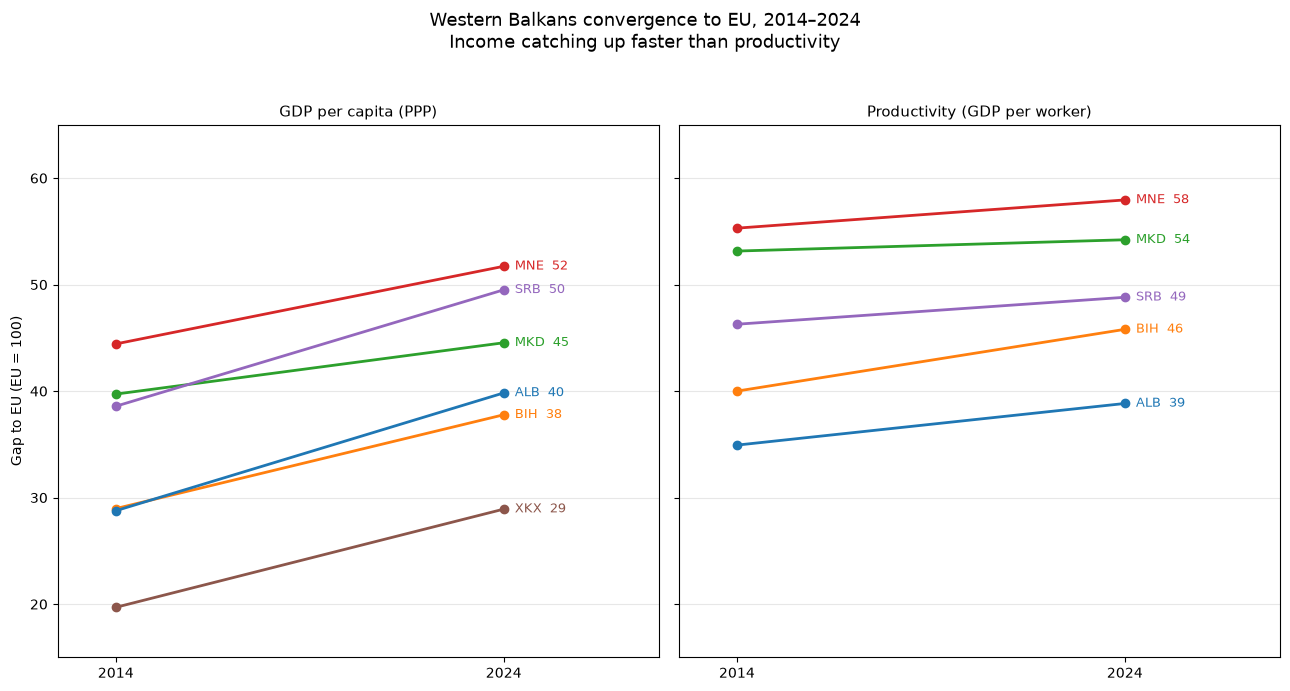

In [7]:
import matplotlib.pyplot as plt

# Slope chart: GDP per capita and productivity, six WB economies, 2014 -> 2024.
# Convergence bucket only. Shared y-axis + FIXED country->colour map so each
# economy keeps one colour across both panels.
conv = stuck_wb[stuck_wb["bucket"] == "convergence"].copy()

# One colour per economy, stable across panels (tab10 palette, hand-assigned)
COUNTRY_COLOURS = {
    "ALB": "#1f77b4",  # blue
    "BIH": "#ff7f0e",  # orange
    "MKD": "#2ca02c",  # green
    "MNE": "#d62728",  # red
    "SRB": "#9467bd",  # purple
    "XKX": "#8c564b",  # brown
}

indicators = [
    ("GDP per capita PPP", "GDP per capita (PPP)"),
    ("Productivity (GDP per worker)", "Productivity (GDP per worker)"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)

for ax, (friendly, title) in zip(axes, indicators):
    panel = conv[conv["friendly_name"] == friendly].dropna(subset=["gap_2014", "gap_2024"])
    panel = panel.sort_values("gap_2024").reset_index(drop=True)
    last_y = None
    for _, row in panel.iterrows():
        colour = COUNTRY_COLOURS[row["country_iso3"]]
        ax.plot([0, 1], [row["gap_2014"], row["gap_2024"]],
                marker="o", linewidth=2, color=colour)
        y = row["gap_2024"]
        if last_y is not None and abs(y - last_y) < 1.5:
            y = last_y + 1.5
        ax.annotate(
            f"{row['country_iso3']}  {row['gap_2024']:.0f}",
            xy=(1, row["gap_2024"]),
            xytext=(8, (y - row["gap_2024"]) * 4),
            textcoords="offset points",
            va="center",
            fontsize=9,
            color=colour,
        )
        last_y = y
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["2014", "2024"])
    ax.set_xlim(-0.15, 1.4)
    ax.set_ylim(15, 65)
    ax.set_title(title, fontsize=11)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Gap to EU (EU = 100)")

fig.suptitle(
    "Western Balkans convergence to EU, 2014–2024\nIncome catching up faster than productivity",
    fontsize=13,
)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [8]:
# Re-pull the rebuilt stuck matrix and verify B-nuanced classification
stuck = pd.read_sql(f"SELECT * FROM {SCHEMA}.wb_fct_stuck_matrix", engine)
stuck_wb = stuck[stuck["country_iso3"].isin(WB_SIX)].copy()

# 1. Every plain-context row must now be not_classified
print("Status by bucket (six WB economies):")
print(stuck_wb.groupby(["bucket", "status"]).size())
print()

# 2. Confirm plain context is ENTIRELY not_classified (no stragglers)
ctx = stuck_wb[stuck_wb["bucket"] == "context"]
print("Plain-context statuses (expect only not_classified):",
      sorted(ctx["status"].unique()))
print()

# 3. Confirm convergence + inverted are UNCHANGED from before the fix
print("Convergence + inverted classifications (should match pre-fix):")
check = stuck_wb[stuck_wb["bucket"].isin(["convergence", "context_inverted"])]
print(
    check[["country_iso3", "friendly_name", "bucket", "gap_change", "status"]]
    .sort_values(["bucket", "friendly_name", "country_iso3"])
    .to_string(index=False)
)

Status by bucket (six WB economies):
bucket            status        
context           not_classified    24
context_inverted  catching_up       10
                  falling_behind     2
convergence       catching_up       10
                  no_data            1
                  stuck              1
dtype: int64

Plain-context statuses (expect only not_classified): ['not_classified']

Convergence + inverted classifications (should match pre-fix):
country_iso3                 friendly_name           bucket  gap_change         status
         ALB        Unemployment total (%) context_inverted      -24.50    catching_up
         BIH        Unemployment total (%) context_inverted      -73.51    catching_up
         MKD        Unemployment total (%) context_inverted      -53.65    catching_up
         MNE        Unemployment total (%) context_inverted       27.87 falling_behind
         SRB        Unemployment total (%) context_inverted      -55.39    catching_up
         XKX        Unem